# Broad-Class WGCNA: First Exploratory Analysis

In this notebook, I run a first-pass weighted gene co-expression network analysis (WGCNA) on **donor-level pseudobulk expression** for one broad cell class at a time. The notebook is parameterised so that I can rerun the same workflow separately for `Excitatory`, `Inhibitory`, `Glia`, and `Vascular`.

I build the network only from the donor-level expression matrix for the chosen broad class. I do **not** use DE tables, DEG lists, log2 fold changes, or p-values to construct the network. I only compare modules with DE results later, as a downstream interpretation step.


## 1. Imports And Setup

I define the broad class to analyse, set up class-specific output folders, and load the Python packages needed for PyWGCNA.


In [ ]:
from pathlib import Path
import sys
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from PyWGCNA import WGCNA

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
PSEUDOBULK_BROAD_DIR = RESULTS_DIR / 'pseudobulk' / 'broad'
DE_BROAD_DIR = RESULTS_DIR / 'de_pseudobulk_broad'
WGCNA_BASE_DIR = RESULTS_DIR / 'wgcna_broad'

FIG_DIR.mkdir(parents=True, exist_ok=True)
WGCNA_BASE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_NAME = 'Excitatory'
VALID_GROUPS = ['Excitatory', 'Inhibitory', 'Glia', 'Vascular']

if GROUP_NAME not in VALID_GROUPS:
    raise ValueError(f'GROUP_NAME must be one of {VALID_GROUPS}.')

WGCNA_DIR = WGCNA_BASE_DIR / GROUP_NAME
WGCNA_DIR.mkdir(parents=True, exist_ok=True)

WGCNA_NAME = f'{GROUP_NAME.lower()}_first_pass'

print('Running WGCNA for broad class:', GROUP_NAME)
print('Output directory:', WGCNA_DIR)


Running WGCNA for broad class: Excitatory
Output directory: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/wgcna_broad/Excitatory


## 2. Load Saved Broad-Class Pseudobulk Expression

I load the donor-level pseudobulk counts and metadata that I previously exported from `10_Peudobulk.ipynb`. This keeps the WGCNA notebook modular and ensures the network is built directly from the broad-class donor expression matrix.


In [ ]:
counts_path = PSEUDOBULK_BROAD_DIR / f'{GROUP_NAME}_counts.csv'
meta_path = PSEUDOBULK_BROAD_DIR / f'{GROUP_NAME}_meta.csv'

if not counts_path.exists() or not meta_path.exists():
    raise FileNotFoundError(
        f'Missing broad-class pseudobulk files for {GROUP_NAME}. '
        'Please rerun notebook 10_Peudobulk.ipynb first.'
    )

counts_df = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

meta_df = meta_df.loc[counts_df.index].copy()

print('Counts matrix:', counts_df.shape)
display(meta_df)
print(meta_df['condition'].value_counts())


Counts matrix: (12, 61552)


,condition,group,groupby_col,n_cells
GSM5292143,sALS,Excitatory,cell_class_major_harmony,2092
GSM5292144,sALS,Excitatory,cell_class_major_harmony,1318
GSM5292145,sALS,Excitatory,cell_class_major_harmony,152
GSM5292146,c9ALS,Excitatory,cell_class_major_harmony,2315
GSM5292147,c9ALS,Excitatory,cell_class_major_harmony,2844
GSM5292148,sALS,Excitatory,cell_class_major_harmony,700
GSM5292156,c9ALS,Excitatory,cell_class_major_harmony,1346
GSM5292157,c9ALS,Excitatory,cell_class_major_harmony,2352
GSM5292174,Control,Excitatory,cell_class_major_harmony,749
GSM5292175,Control,Excitatory,cell_class_major_harmony,756


condition
sALS       4
c9ALS      4
Control    4
Name: count, dtype: int64


In [ ]:
counts_df.to_csv(WGCNA_DIR / f'{GROUP_NAME}_pseudobulk_counts_raw.csv')
meta_df.to_csv(WGCNA_DIR / f'{GROUP_NAME}_pseudobulk_metadata.csv')


## 3. Filter And Transform Genes For Network Analysis

I do **not** run WGCNA on all genes. Instead, I:

- remove genes with extremely sparse counts across donors
- transform counts to log-CPM
- keep the most variable genes for a first-pass network analysis

This is especially important here because the donor-level sample size is modest.


In [ ]:
MIN_COUNT = 10
MIN_SAMPLES = 4
TOP_N_VARIABLE_GENES = 5000

# I first remove genes that are barely detected across donors.
keep_detected = (counts_df >= MIN_COUNT).sum(axis=0) >= MIN_SAMPLES
counts_detected = counts_df.loc[:, keep_detected].copy()

# I then compute log-CPM so the network is built on transformed donor-level expression.
libsize = counts_detected.sum(axis=1)
log_cpm = np.log1p(counts_detected.div(libsize, axis=0) * 1e6)

# For a first-pass exploratory network, I keep the most variable genes by MAD.
gene_medians = log_cpm.median(axis=0)
gene_mad = log_cpm.sub(gene_medians, axis=1).abs().median(axis=0).sort_values(ascending=False)
selected_genes = gene_mad.head(min(TOP_N_VARIABLE_GENES, gene_mad.shape[0])).index
expr_wgcna = log_cpm.loc[:, selected_genes].copy()

print('Raw pseudobulk matrix:', counts_df.shape)
print('After detection filter:', counts_detected.shape)
print('Final WGCNA matrix:', expr_wgcna.shape)


Raw pseudobulk matrix: (12, 61552)
After detection filter: (12, 24248)
Final WGCNA matrix: (12, 5000)


In [ ]:
expr_wgcna.to_csv(WGCNA_DIR / f'{GROUP_NAME}_logCPM_for_wgcna.csv')


## 4. Create The PyWGCNA Input Object

PyWGCNA expects an expression matrix with **samples as rows** and **genes as columns**, plus sample metadata and gene metadata. I create that object explicitly so I can inspect every step.


In [ ]:
sample_info = meta_df.copy()
sample_info['condition'] = sample_info['condition'].astype(str)

gene_info = pd.DataFrame(index=expr_wgcna.columns)
gene_info['gene_id'] = gene_info.index.astype(str)
gene_info['gene_name'] = gene_info.index.astype(str)

wgcna_ad = ad.AnnData(
    X=expr_wgcna.values,
    obs=sample_info.loc[expr_wgcna.index].copy(),
    var=gene_info.loc[expr_wgcna.columns].copy(),
)

print(wgcna_ad)
display(wgcna_ad.obs.head())
display(wgcna_ad.var.head())


AnnData object with n_obs × n_vars = 12 × 5000
    obs: 'condition', 'group', 'groupby_col', 'n_cells'
    var: 'gene_id', 'gene_name'


,condition,group,groupby_col,n_cells
GSM5292143,sALS,Excitatory,cell_class_major_harmony,2092
GSM5292144,sALS,Excitatory,cell_class_major_harmony,1318
GSM5292145,sALS,Excitatory,cell_class_major_harmony,152
GSM5292146,c9ALS,Excitatory,cell_class_major_harmony,2315
GSM5292147,c9ALS,Excitatory,cell_class_major_harmony,2844


,gene_id,gene_name
PI4KAP1,PI4KAP1,PI4KAP1
ANKRD20A11P,ANKRD20A11P,ANKRD20A11P
TSIX,TSIX,TSIX
VGF,VGF,VGF
LINC00903,LINC00903,LINC00903


## 5. Initialise The PyWGCNA Analysis

I use a relatively conservative, first-pass set of parameters. Because this is an exploratory donor-level network with a limited number of samples, I keep the settings interpretable rather than aggressive.


In [ ]:
wgcna = WGCNA(
    name=WGCNA_NAME,
    species='Human',
    anndata=wgcna_ad,
    outputPath=str(WGCNA_DIR) + '/',
    save=True,
    figureType='png',
    TPMcutoff=0,
    cut=float('inf'),
    powers=list(range(1, 11)) + list(range(12, 21, 2)),
    RsquaredCut=0.80,
    MeanCut=100,
    networkType='signed hybrid',
    TOMType='signed',
    minModuleSize=30,
    MEDissThres=0.2,
)


Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!


## 6. Preprocess Samples And Run Module Detection

This follows the main PyWGCNA workflow:

- preprocess samples / genes
- choose a soft threshold
- build the co-expression network
- identify modules


Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  5000
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.277551  0.345312       0.903563  1636.661861  1879.983094   
1       2  0.001346 -0.018359       0.522703  1036.376748   1154.28573   
2       3  0.153128 -0.209871       0.212077   737.812655   787.830155   
3       4  0.318844 -0.324145       0.223692   560.267656   569.758512   
4       5  0.466067 -0.408039       0.330666   443.303299   428.867607   
5       6  0.556444 -0.487948       0.431052   360.962944   332.064401   
6       7  0.642647 -0.546996         0.5629    300.23759   262.539306   
7       8  0.702839 -0.601908       0.668885   253.882559   210.361382   
8       9  0.732315 -0.643345       0.730367    217.54237    170.74029   
9      10  0.755492 -0.687129       0.785351   188.441

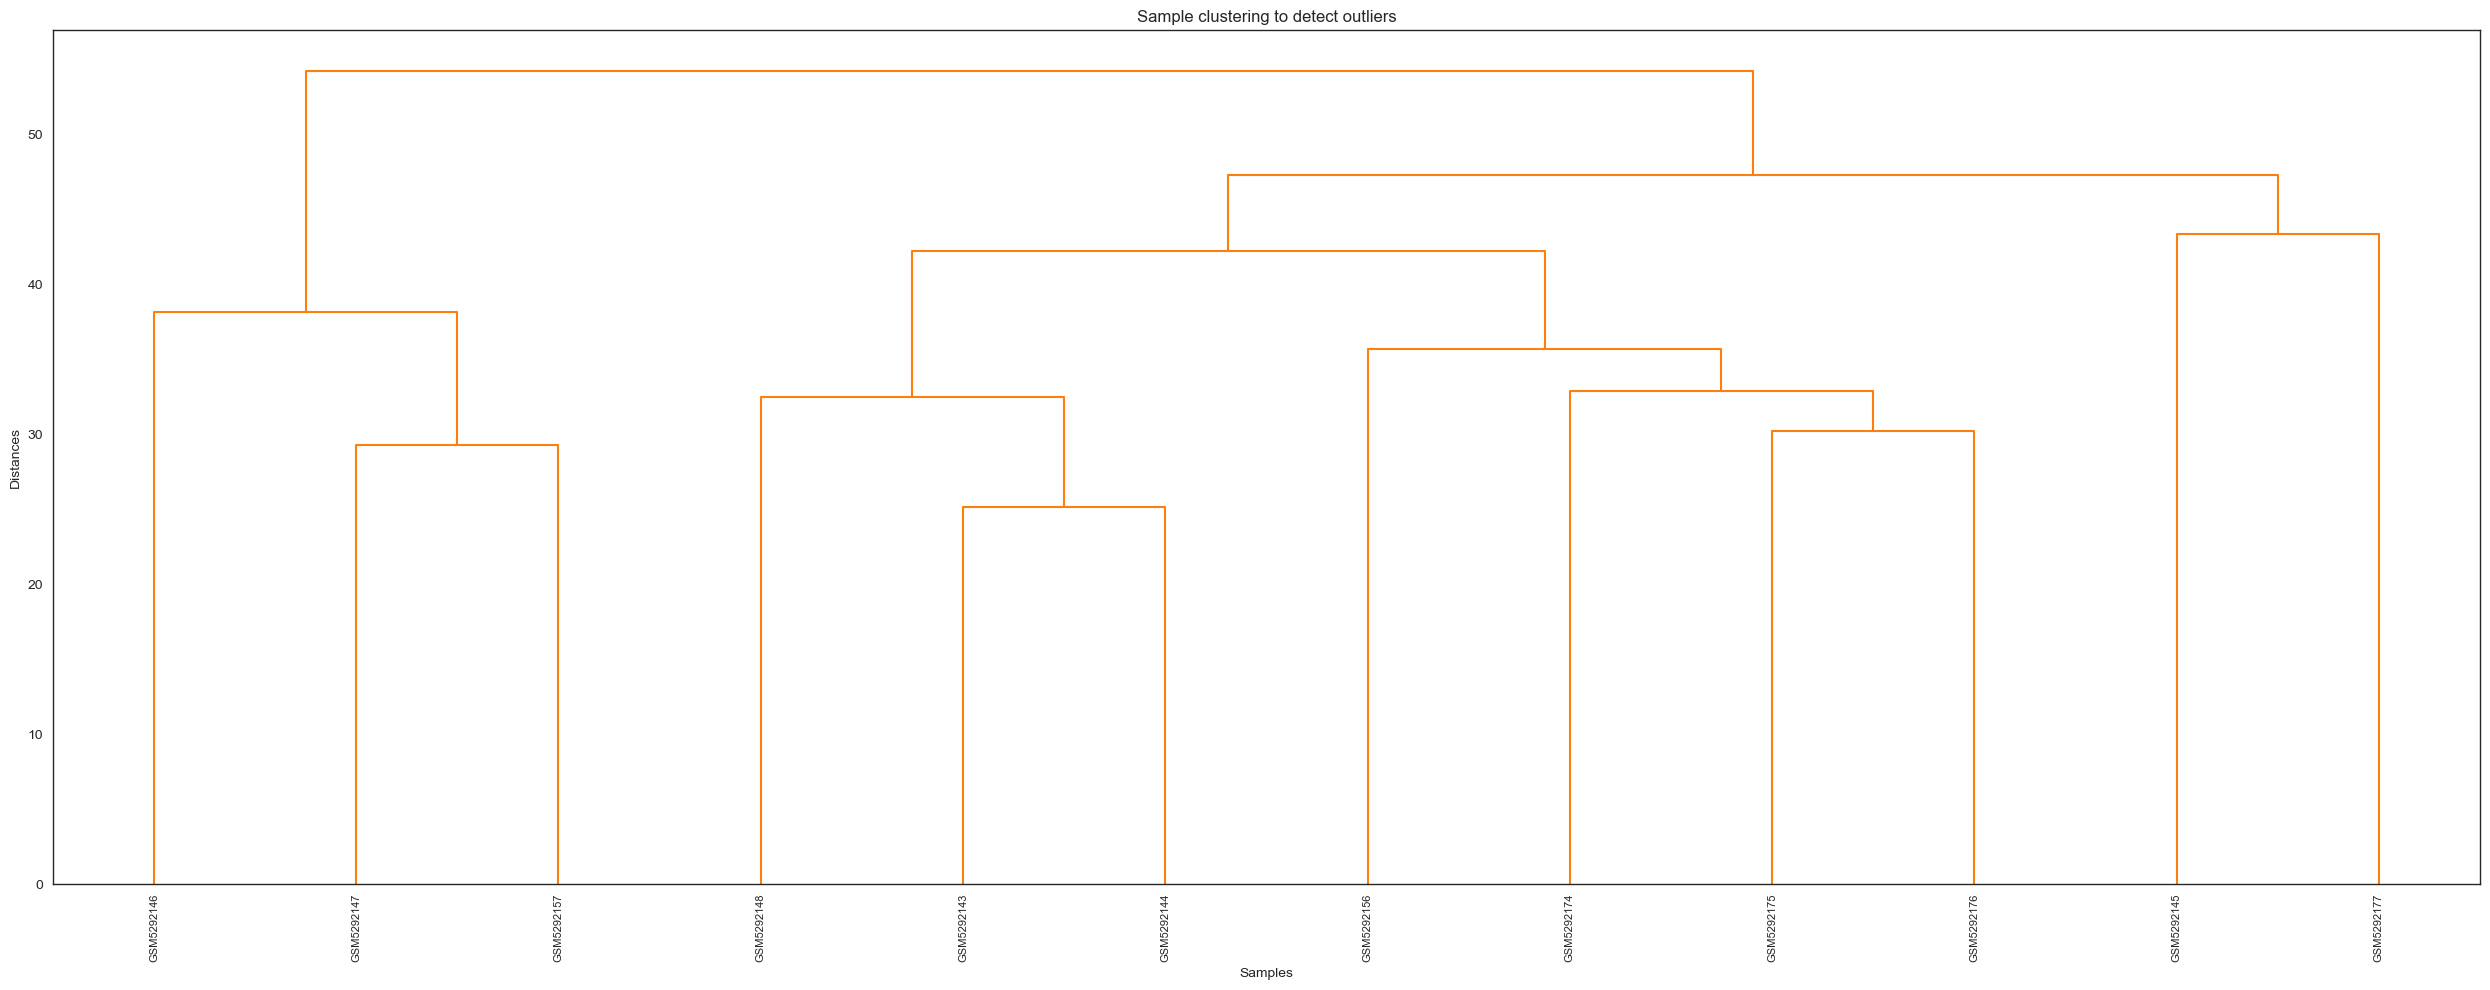

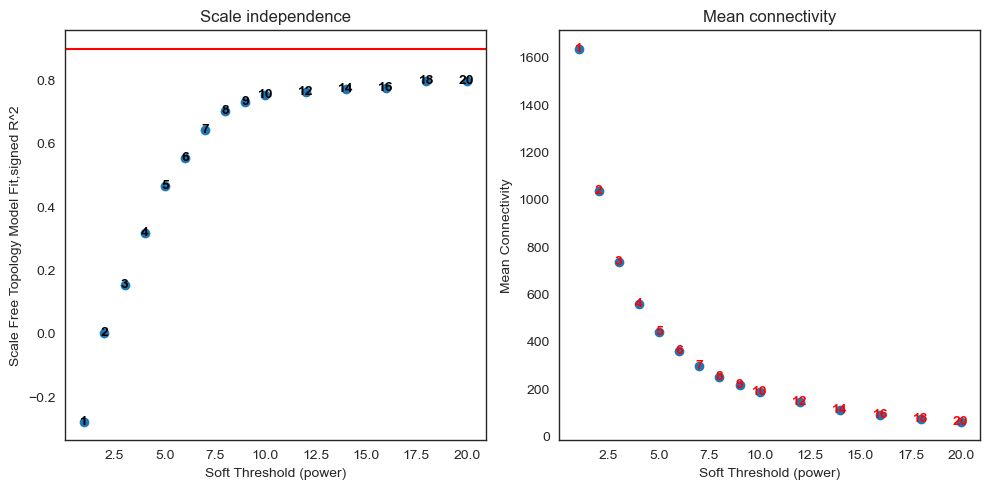

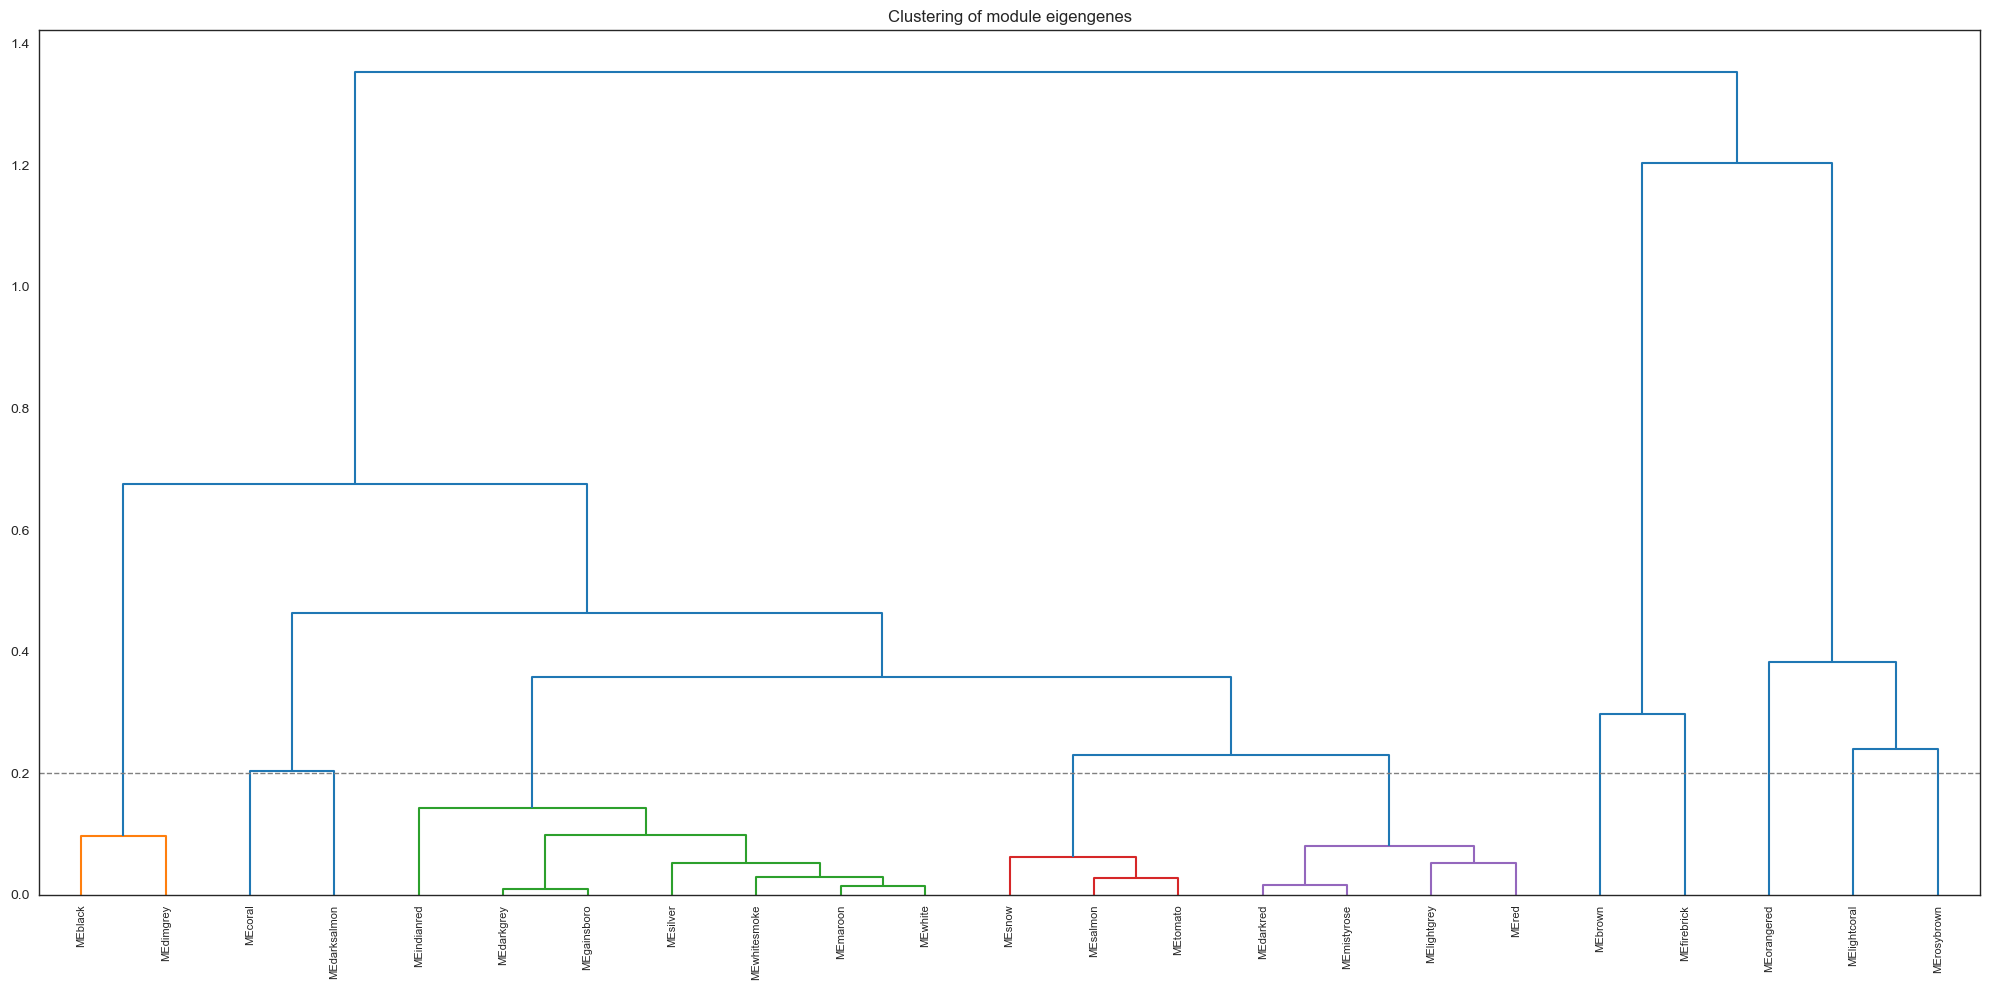

In [ ]:
wgcna.preprocess(show=True)
wgcna.findModules(
    kwargs_function={
        'cutreeHybrid': {
            'deepSplit': 2,
            'pamRespectsDendro': False,
        }
    }
)

wgcna.saveWGCNA()


## 7. Inspect Module Sizes

I first check how many modules were detected and how many genes ended up in each module.


,module,n_genes
0,black,1598
1,indianred,1559
2,orangered,575
3,darkred,430
4,salmon,368
5,brown,147
6,rosybrown,131
7,firebrick,121
8,coral,33
9,lightcoral,22


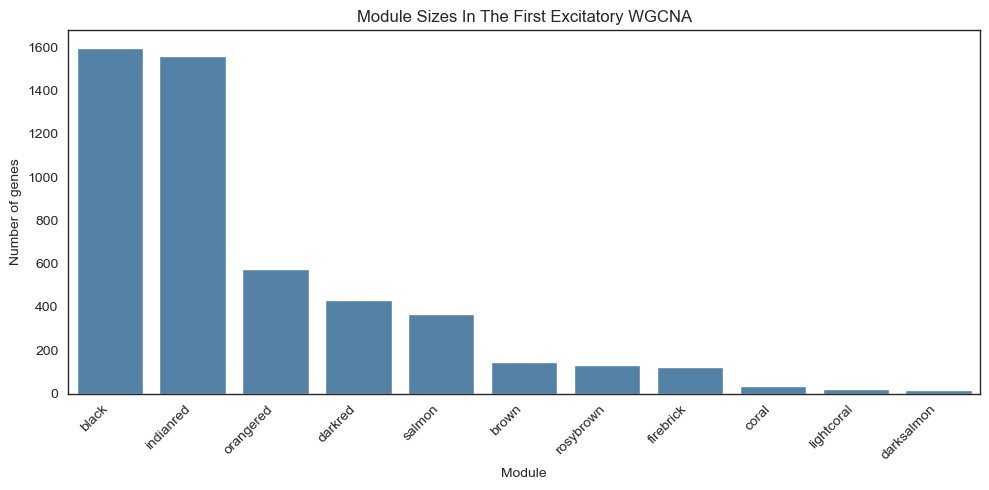

In [ ]:
module_sizes = wgcna.datExpr.var['moduleColors'].value_counts().rename_axis('module').reset_index(name='n_genes')
module_sizes = module_sizes.sort_values('n_genes', ascending=False)
display(module_sizes)

plt.figure(figsize=(10, 5))
sns.barplot(data=module_sizes, x='module', y='n_genes', color='steelblue')
plt.title(f'Module Sizes In The First {GROUP_NAME} WGCNA')
plt.xlabel('Module')
plt.ylabel('Number of genes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 8. Relate Modules To Disease Status

I now test whether module eigengenes correlate with the donor-level metadata I provided. Here, the key trait is `condition`, and I also keep `n_cells` so I can see whether any module is mainly tracking pseudobulk cell yield.


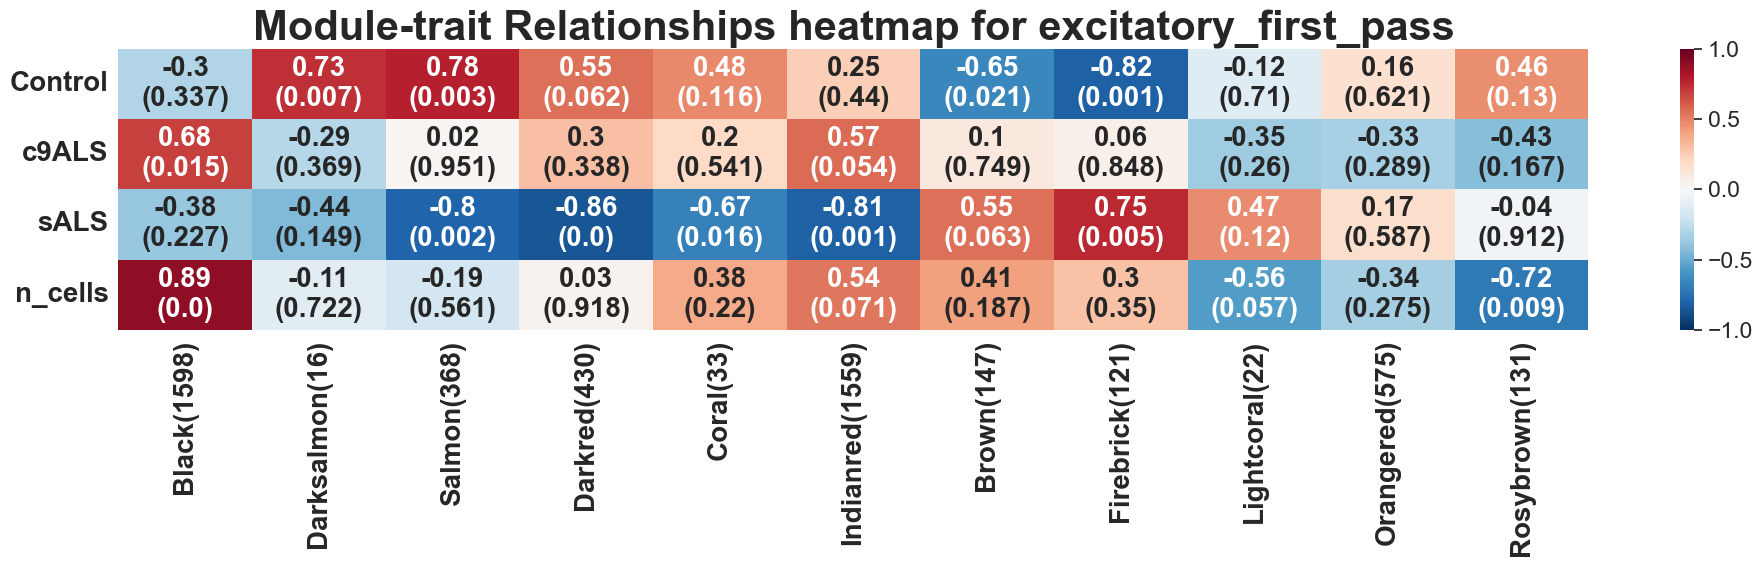

In [ ]:
condition_palette = {
    'Control': '#4C78A8',
    'sALS': '#F58518',
    'c9ALS': '#54A24B',
}

wgcna.setMetadataColor('condition', condition_palette)
wgcna.module_trait_relationships_heatmap(
    metaData=wgcna.datExpr.obs.columns.tolist(),
    show=True,
    file_name=f'{WGCNA_NAME}_module_trait_relationships',
)


In [ ]:
trait_results = (
    wgcna.moduleTraitCor.stack().rename('correlation').to_frame()
    .join(wgcna.moduleTraitPvalue.stack().rename('pvalue'))
    .reset_index()
    .rename(columns={'level_0': 'module', 'level_1': 'trait'})
)
trait_results['abs_correlation'] = trait_results['correlation'].abs()
trait_results = trait_results.sort_values(['pvalue', 'abs_correlation'], ascending=[True, False])

display(trait_results.head(20))


,module,trait,correlation,pvalue,abs_correlation
3,MEblack,n_cells,0.886634,0.000122,0.886634
14,MEdarkred,sALS,-0.856197,0.000378,0.856197
28,MEfirebrick,Control,-0.815146,0.001235,0.815146
22,MEindianred,sALS,-0.814343,0.001260,0.814343
10,MEsalmon,sALS,-0.797002,0.001909,0.797002
8,MEsalmon,Control,0.777185,0.002934,0.777185
30,MEfirebrick,sALS,0.752984,0.004701,0.752984
4,MEdarksalmon,Control,0.728033,0.007263,0.728033
43,MErosybrown,n_cells,-0.715537,0.008884,0.715537
1,MEblack,c9ALS,0.681005,0.014764,0.681005


## 9. Select Disease-Relevant Modules For Follow-Up

For a first pass, I focus on modules that show the strongest relationship with the disease labels. If nothing passes a strict threshold, I still keep the top few modules for exploratory follow-up.


In [ ]:
condition_traits = sorted(meta_df['condition'].astype(str).unique().tolist())
trait_hits = trait_results[trait_results['trait'].isin(condition_traits)].copy()
trait_hits = trait_hits.sort_values(['pvalue', 'abs_correlation'], ascending=[True, False])

display(trait_hits.head(20))

interesting_modules = (
    trait_hits.loc[trait_hits['pvalue'] < 0.10, 'module']
    .str.replace('^ME', '', regex=True)
    .drop_duplicates()
    .tolist()
)

if len(interesting_modules) == 0:
    interesting_modules = (
        trait_hits['module']
        .str.replace('^ME', '', regex=True)
        .drop_duplicates()
        .head(3)
        .tolist()
    )

print('Modules selected for follow-up:', interesting_modules)


,module,trait,correlation,pvalue,abs_correlation
14,MEdarkred,sALS,-0.856197,0.000378,0.856197
28,MEfirebrick,Control,-0.815146,0.001235,0.815146
22,MEindianred,sALS,-0.814343,0.001260,0.814343
10,MEsalmon,sALS,-0.797002,0.001909,0.797002
8,MEsalmon,Control,0.777185,0.002934,0.777185
30,MEfirebrick,sALS,0.752984,0.004701,0.752984
4,MEdarksalmon,Control,0.728033,0.007263,0.728033
1,MEblack,c9ALS,0.681005,0.014764,0.681005
18,MEcoral,sALS,-0.673955,0.016250,0.673955
24,MEbrown,Control,-0.654571,0.020904,0.654571


Modules selected for follow-up: ['darkred', 'firebrick', 'indianred', 'salmon', 'darksalmon', 'black', 'coral', 'brown']


## 10. Plot Eigengenes For The Most Relevant Modules

I plot module eigengenes by condition so I can see whether the module-level effect is broad and consistent across donors.


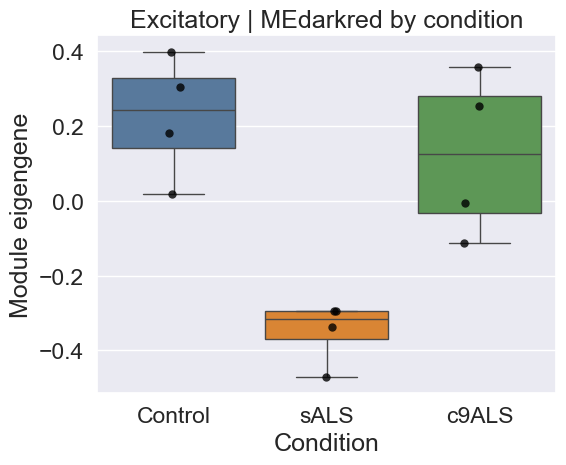

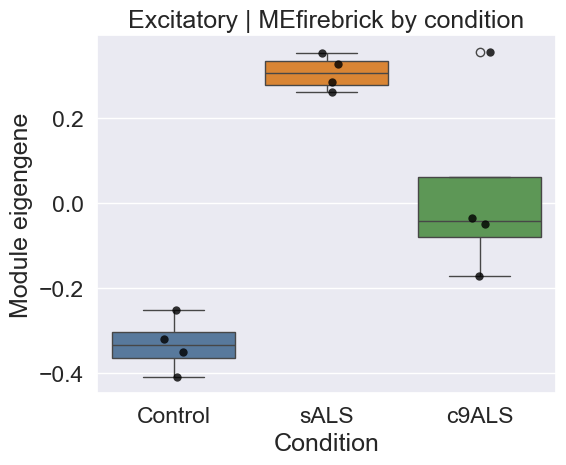

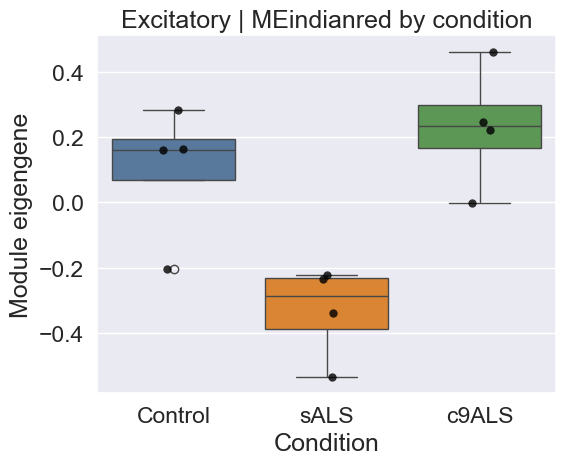

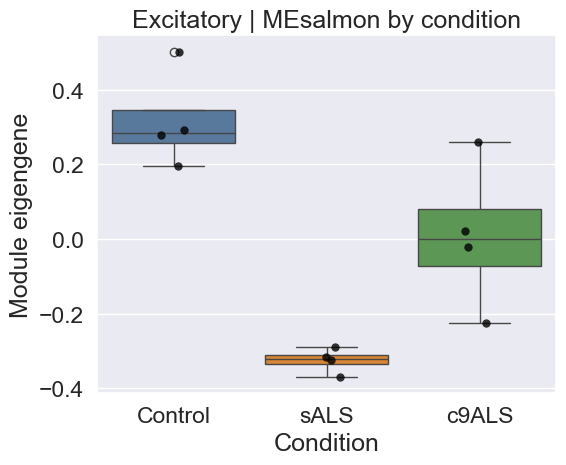

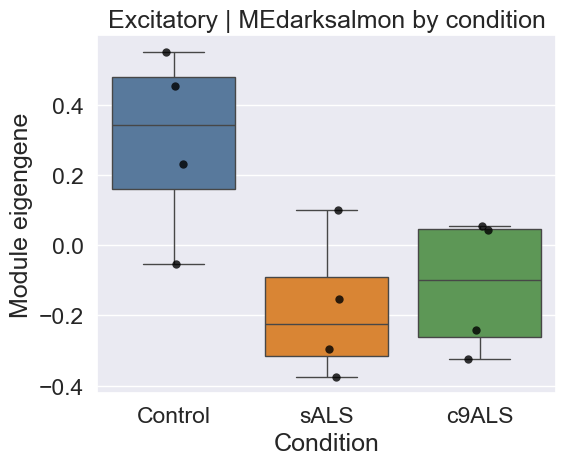

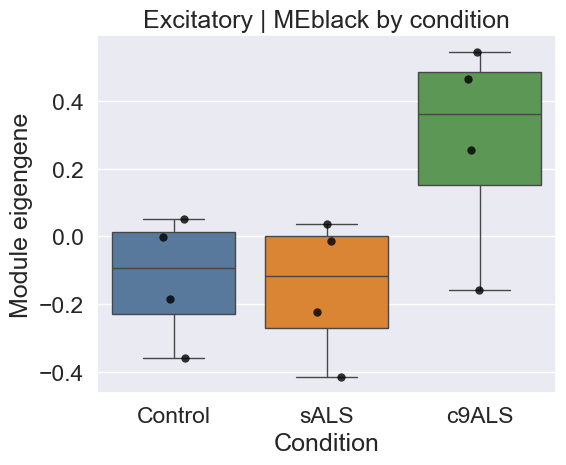

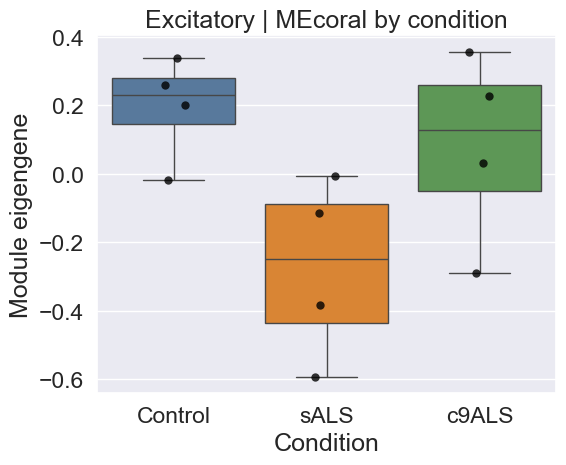

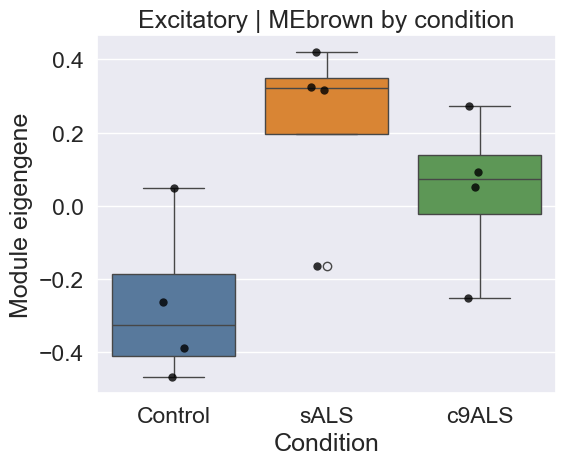

In [ ]:
module_eigengenes = wgcna.datME.copy()
module_eigengenes['condition'] = wgcna.datExpr.obs['condition'].values
module_eigengenes['n_cells'] = wgcna.datExpr.obs['n_cells'].values
module_eigengenes.index.name = 'sample'

for module in interesting_modules:
    me_col = f'ME{module}'
    if me_col not in module_eigengenes.columns:
        continue

    plt.figure(figsize=(6, 5))
    sns.boxplot(
        data=module_eigengenes,
        x='condition',
        y=me_col,
        order=['Control', 'sALS', 'c9ALS'],
        palette=condition_palette,
    )
    sns.stripplot(
        data=module_eigengenes,
        x='condition',
        y=me_col,
        order=['Control', 'sALS', 'c9ALS'],
        color='black',
        size=6,
        alpha=0.8,
    )
    plt.title(f'{GROUP_NAME} | {me_col} by condition')
    plt.xlabel('Condition')
    plt.ylabel('Module eigengene')
    plt.tight_layout()
    plt.show()


## 11. Inspect Hub Genes In The Modules Of Interest

Hub genes give me a first biological handle on what each disease-associated module might represent.


In [ ]:
hub_gene_tables = {}

for module in interesting_modules:
    hub_gene_tables[module] = wgcna.top_n_hub_genes(moduleName=module, n=15)
    print(f"\nTop hub genes for module: {module}")
    display(hub_gene_tables[module])


calculating adjacency matrix ...
	Done..


Top hub genes for module: darkred


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
AGPAT1,75.526759,AGPAT1,AGPAT1,darkred,darkred,3
C11orf68,67.583702,C11orf68,C11orf68,darkred,darkred,3
SLC25A22,66.439754,SLC25A22,SLC25A22,darkred,darkred,3
DMTN,66.366712,DMTN,DMTN,darkred,darkred,3
CDC34,65.545596,CDC34,CDC34,darkred,darkred,3
ADAD2,64.081878,ADAD2,ADAD2,darkred,darkred,3
UBALD1,63.487181,UBALD1,UBALD1,darkred,darkred,3
TLE5,61.304805,TLE5,TLE5,darkred,darkred,3
RNF187,61.296987,RNF187,RNF187,darkred,darkred,3
FNDC10,60.667883,FNDC10,FNDC10,darkred,darkred,3


calculating adjacency matrix ...
	Done..


Top hub genes for module: firebrick


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
STX10,8.599494,STX10,STX10,firebrick,firebrick,5
MCRIP2,7.841575,MCRIP2,MCRIP2,firebrick,firebrick,5
DXO,7.665329,DXO,DXO,firebrick,firebrick,5
PCYT2,7.438802,PCYT2,PCYT2,firebrick,firebrick,5
COASY,7.414400,COASY,COASY,firebrick,firebrick,5
RNF166,7.169872,RNF166,RNF166,firebrick,firebrick,5
MIR4453HG,6.938001,MIR4453HG,MIR4453HG,firebrick,firebrick,5
RBM8A,6.815004,RBM8A,RBM8A,firebrick,firebrick,5
ENSG00000288904,6.768618,ENSG00000288904,ENSG00000288904,firebrick,firebrick,5
ZNF649,6.460420,ZNF649,ZNF649,firebrick,firebrick,5


calculating adjacency matrix ...
	Done..


Top hub genes for module: indianred


...

,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
ENSG00000267131,363.991534,ENSG00000267131,ENSG00000267131,black,black,0
ENSG00000223646,363.040378,ENSG00000223646,ENSG00000223646,black,black,0
GTF2I-AS1,354.380438,GTF2I-AS1,GTF2I-AS1,black,black,0
ENSG00000285530,351.641502,ENSG00000285530,ENSG00000285530,black,black,0
ENSG00000233783,347.402637,ENSG00000233783,ENSG00000233783,black,black,0
ENSG00000261632,344.080705,ENSG00000261632,ENSG00000261632,black,black,0
ENSG00000286244,340.820682,ENSG00000286244,ENSG00000286244,black,black,0
ENSG00000223732,338.257986,ENSG00000223732,ENSG00000223732,black,black,0
ENSG00000265204,337.609191,ENSG00000265204,ENSG00000265204,black,black,0
MTCP1,337.141970,MTCP1,MTCP1,black,black,0


calculating adjacency matrix ...
	Done..


Top hub genes for module: coral


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
CTSZ,3.240971,CTSZ,CTSZ,coral,coral,2
NLRP8,2.955729,NLRP8,NLRP8,coral,coral,2
ENSG00000223390,2.649012,ENSG00000223390,ENSG00000223390,coral,coral,2
CYSTM1,2.507592,CYSTM1,CYSTM1,coral,coral,2
ENSG00000277675,2.469125,ENSG00000277675,ENSG00000277675,coral,coral,2
IL17RE,2.387176,IL17RE,IL17RE,coral,coral,2
MORC2-AS1,2.190127,MORC2-AS1,MORC2-AS1,coral,coral,2
ENSG00000232220,1.683198,ENSG00000232220,ENSG00000232220,coral,coral,2
ENSG00000274315,1.552274,ENSG00000274315,ENSG00000274315,coral,coral,2
LINC02008,1.482748,LINC02008,LINC02008,coral,coral,2


calculating adjacency matrix ...
	Done..


Top hub genes for module: brown


,connectivity,gene_id,gene_name,dynamicColors,moduleColors,moduleLabels
THSD7A,4.733200,THSD7A,THSD7A,brown,brown,1
ITGA4,4.334317,ITGA4,ITGA4,brown,brown,1
ENSG00000253762,4.296830,ENSG00000253762,ENSG00000253762,brown,brown,1
LINC01289,4.279912,LINC01289,LINC01289,brown,brown,1
PRSS12,4.270149,PRSS12,PRSS12,brown,brown,1
EPB41L2,4.047069,EPB41L2,EPB41L2,brown,brown,1
EPHA6,3.854107,EPHA6,EPHA6,brown,brown,1
TMEM132E,3.773413,TMEM132E,TMEM132E,brown,brown,1
LINC01484,3.749709,LINC01484,LINC01484,brown,brown,1
CHRDL1,3.677723,CHRDL1,CHRDL1,brown,brown,1


## 12. Compare WGCNA Modules With Broad-Class DE Results

I compare module genes back to the broad-class differential expression signatures that I already generated. This step is only for interpretation and does **not** feed back into network construction.


In [ ]:
de_comparisons = ['Control_vs_sALS', 'Control_vs_c9ALS', 'sALS_vs_c9ALS']

de_gene_sets = {}
for comparison in de_comparisons:
    de_path = DE_BROAD_DIR / f'{GROUP_NAME}_{comparison}.csv'
    if not de_path.exists():
        print(f'Skipping DE overlap for missing file: {de_path}')
        continue

    de_df = pd.read_csv(de_path)
    de_df = de_df.dropna(subset=['padj', 'log2FoldChange']).copy()
    de_gene_sets[comparison] = set(
        de_df.loc[
            (de_df['padj'] < 0.10) & (de_df['log2FoldChange'].abs() > 0.25),
            'gene'
        ].astype(str)
    )

overlap_rows = []
for module in interesting_modules:
    module_genes = set(
        wgcna.datExpr.var.index[wgcna.datExpr.var['moduleColors'] == module].astype(str)
    )
    for comparison, sig_genes in de_gene_sets.items():
        overlap_rows.append({
            'module': module,
            'comparison': comparison,
            'module_size': len(module_genes),
            'n_sig_de': len(sig_genes),
            'overlap_n': len(module_genes & sig_genes),
            'overlap_genes': ', '.join(sorted(module_genes & sig_genes)[:20]),
        })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)


,module,comparison,module_size,n_sig_de,overlap_n,overlap_genes
0,darkred,Control_vs_sALS,430,4307,339,"ACKR1, ACLY, ACTB, ADAD2, ADAP1, AGPAT1, AJM1,..."
1,darkred,Control_vs_c9ALS,430,1705,11,"ALDH1L1, BCRP2, CCN1, ENSG00000249258, ENSG000..."
2,darkred,sALS_vs_c9ALS,430,5107,204,"ADAP1, AGPAT1, ALDH1A3, AMIGO1, ANAPC13, ARL2B..."
3,firebrick,Control_vs_sALS,121,4307,112,"ABCC3, ADAT1, ALG1L11P, ARHGEF25, ASPDH, ATXN1..."
4,firebrick,Control_vs_c9ALS,121,1705,22,"ABCC3, ADAT1, DCTN1, DDR2, ENSG00000176593, EN..."
5,firebrick,sALS_vs_c9ALS,121,5107,37,"BBS2, BCAN, CARD19, COASY, CRHR2, DIRC3-AS1, D..."
6,indianred,Control_vs_sALS,1559,4307,748,"A2MP1, AAMP, ABCA1, ABCC6, ABHD8, ACP2, ACTG1,..."
7,indianred,Control_vs_c9ALS,1559,1705,58,"AASS, ADAMTS18, ARC, ARPP19, ATF3, ATP5F1E, CA..."
8,indianred,sALS_vs_c9ALS,1559,5107,1112,"A2ML1, A2MP1, A3GALT2, AAMP, AASS, ABCC6, ABHD..."
9,salmon,Control_vs_sALS,368,4307,288,"ABCA7, ABHD17A, ABTB1, ACADVL, ACHE, ADAM11, A..."


## 13. Run First-Pass Functional Enrichment For Modules Of Interest

PyWGCNA can run enrichment analysis directly. These calls rely on online resources, so they require an internet connection when I execute them.

For a first pass, I focus on:

- GO biological process enrichment
- Reactome pathway enrichment

This is the step where I can ask whether disease-associated modules point towards pathways such as immune activation, lysosomal biology, oxidative phosphorylation, synaptic biology, or proteostasis.


In [ ]:
# I leave this cell ready to run when I want online enrichment.
for module in interesting_modules:
    print(f'Running enrichment for module: {module}')
    wgcna.functional_enrichment_analysis(
        type='GO',
        moduleName=module,
        sets=['GO_Biological_Process_2021'],
        p_value=0.05,
        file_name=f'{GROUP_NAME}_{module}_GO_BP',
    )
    wgcna.functional_enrichment_analysis(
        type='REACTOME',
        moduleName=module,
        p_value=0.05,
        file_name=f'{GROUP_NAME}_{module}_Reactome',
    )


Running enrichment for module: darkred
GO directory does not exist!
Creating excitatory_first_pass_GO directory!
No enrich terms when cutoff = 0.05 in module darkred
REACTOME directory does not exist!
Creating excitatory_first_pass_REACTOME directory!
Status code returned a value of 404
238 out of 430 genes (identifiers) in the sample were found in Reactome.
6721 pathways were hit by at least one of them, which 1 of them have p-value less than 0.05.
Report was saved /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/wgcna_broad/Excitatory/figures/excitatory_first_pass_REACTOME/Excitatory_darkred_Reactome.png!
For more information please visit https://reactome.org/PathwayBrowser/#/DTAB=AN&ANALYSIS=MjAyNjA0MjMxOTM1MTRfMjExNDY%3D
Running enrichment for module: firebrick
No enrich terms when cutoff = 0.05 in module firebrick
Status code returned a value of 404
39 out of 121 genes (identifiers) in the sample were found in Reactome.
1507 pathways were hit by at least

## 14. Notes For Interpretation

At this stage, I want to ask four main questions:

1. which module eigengenes separate `sALS`, `c9ALS`, and `Control` within this broad class?
2. do the strongest modules recapitulate the biology I already saw in my broad-class DE analysis?
3. do the hub genes in those modules make biological sense for this cell class?
4. do enrichment results highlight pathways that are relevant to disease biology in this broad class?

If this first pass is promising, the next step would be to refine the analysis further by:

- tuning gene filtering thresholds
- checking module robustness
- comparing module membership with targeted gene sets of interest
- extending the workflow across the other broad classes
